# Démo rapide — TriPlane Rep-SliceMix-Net

Ce notebook charge un modèle **déjà entraîné**, l'évalue sur les sujets de validation de son fold et affiche quelques segmentations. Il ne lance aucun entraînement et ne modifie ni le checkpoint ni les données.

> Les métriques ci-dessous concernent le fold de validation local, pas le jeu de test caché iSeg-2017. Le checkpoint par défaut est le B0 final du fold 0.

## Utilisation

1. Ouvrir le dépôt dans Jupyter ou VS Code avec l'environnement Python du projet.
2. Vérifier les paramètres de la cellule **Configuration**.
3. Exécuter toutes les cellules.

Le mode tri-plan reproduit l'évaluation de référence. Pour une démo plus courte, remplacer `PLANES = (0, 1, 2)` par `PLANES = (0,)` ; le score obtenu ne sera alors plus directement comparable à celui de la model card.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np
import torch

# Fonctionne que Jupyter soit lancé depuis la racine ou depuis notebooks/.
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'pyproject.toml').is_file():
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').is_file():
    raise RuntimeError('Racine du dépôt brainviz introuvable.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from brainviz.config import build_model, load_splits
from brainviz.inference import predict_preprocessed
from brainviz.models import count_parameters
from brainviz.training.metrics import segmentation_metrics

print(f'Projet : {ROOT}')
print(f'PyTorch : {torch.__version__} | CUDA disponible : {torch.cuda.is_available()}')

Projet : /home/laq/brainviz
PyTorch : 2.14.0+cu130 | CUDA disponible : True


In [2]:
# Configuration de la démo
CHECKPOINT = ROOT / 'artifacts/rep_slicemix/runs/fold0-20260903-233524/checkpoint_best_triplane.pt'
FOLD = 0
PLANES = (0, 1, 2)       # (0,) = axial rapide ; (0, 1, 2) = score de référence
SLICE_SPACINGS = (1,)    # d=1 retenu après l'ablation TTA
BATCH_SIZE = 32
MAX_SUBJECTS = None      # 1 pour une démo express, None pour tout le fold
DISPLAY_SUBJECT_INDEX = 0

if not CHECKPOINT.is_file():
    raise FileNotFoundError(
        f'Checkpoint introuvable : {CHECKPOINT}\n'
        'Modifier CHECKPOINT pour pointer vers checkpoint_best_triplane.pt.'
    )

## Chargement du checkpoint

Les poids EMA sont utilisés, comme pendant la validation. Les branches reparamétrables sont ensuite fusionnées pour obtenir le modèle de déploiement sans changer ses prédictions.

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(CHECKPOINT, map_location='cpu', weights_only=False)
config = checkpoint['config']
model = build_model(config).eval()
training_parameters = count_parameters(model)

if checkpoint.get('reparameterized', False):
    if not hasattr(model, 'reparameterize'):
        raise ValueError('Le checkpoint est fusionné mais le modèle ne peut pas être reparamétré.')
    model.reparameterize()
    model.load_state_dict(checkpoint['model'])
else:
    model.load_state_dict(checkpoint.get('ema', checkpoint['model']))
    if hasattr(model, 'reparameterize'):
        model.reparameterize()

model = model.to(DEVICE).eval()
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(DEVICE)}')
print(f'Checkpoint : {CHECKPOINT.relative_to(ROOT)}')
print(f'Epoch : {checkpoint["epoch"] + 1} | itérations : {checkpoint["global_step"]:,}')
print(f'Paramètres : {training_parameters:,} entraînement → {count_parameters(model):,} déploiement')

Device : cuda
GPU : NVIDIA GeForce RTX 5070 Ti
Checkpoint : artifacts/rep_slicemix/runs/fold0-20260903-233524/checkpoint_best_triplane.pt
Epoch : 200 | itérations : 50,000
Paramètres : 548,516 entraînement → 543,380 déploiement


In [4]:
def project_path(value):
    path = Path(value)
    return path if path.is_absolute() else ROOT / path

splits = load_splits(project_path(config['data']['splits']))
if not 0 <= FOLD < len(splits):
    raise ValueError(f'FOLD doit être compris entre 0 et {len(splits) - 1}.')
subject_ids = splits[FOLD]['val'][:MAX_SUBJECTS]
preprocessed_dir = project_path(config['data']['preprocessed_dir'])
subject_paths = [preprocessed_dir / f'{subject_id}.npz' for subject_id in subject_ids]
missing = [str(path) for path in subject_paths if not path.is_file()]
if missing:
    raise FileNotFoundError('Volumes prétraités manquants :\n' + '\n'.join(missing))

print(f'Fold {FOLD} — validation : {", ".join(subject_ids)}')
print(f'Vues : {len(PLANES) * len(SLICE_SPACINGS)} | plans={PLANES}, espacements={SLICE_SPACINGS}')

Fold 0 — validation : iseg_001, iseg_008
Vues : 3 | plans=(0, 1, 2), espacements=(1,)


## Inférence et évaluation volumique

Chaque volume est reconstruit dans l'espace canonique prétraité. Les métriques sont calculées en 3D pour CSF, GM et WM, puis moyennées entre sujets.

In [5]:
records = []
total_start = time.perf_counter()

for subject_id, subject_path in zip(subject_ids, subject_paths, strict=True):
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    start = time.perf_counter()
    probabilities, metadata = predict_preprocessed(
        model,
        subject_path,
        planes=PLANES,
        slice_spacings=SLICE_SPACINGS,
        batch_size=BATCH_SIZE,
        device=DEVICE,
        amp=DEVICE.type == 'cuda',
    )
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    with np.load(subject_path, allow_pickle=False) as archive:
        if 'label' not in archive.files:
            raise ValueError(f'{subject_path.name} ne contient pas de label.')
        t1 = archive['t1'].copy()
        t2 = archive['t2'].copy()
        target = archive['label'].copy()

    prediction = probabilities.argmax(axis=0).astype(np.uint8)
    metrics = segmentation_metrics(prediction, target, tuple(metadata['spacing']))
    records.append({
        'id': subject_id,
        'seconds': elapsed,
        'metrics': metrics,
        't1': t1,
        't2': t2,
        'target': target,
        'prediction': prediction,
        'confidence': probabilities.max(axis=0),
    })
    print(f'{subject_id} terminé en {elapsed:.2f} s — Dice moyen {metrics["mean_dice"]:.5f}')

print(f'Temps total : {time.perf_counter() - total_start:.2f} s')

iseg_001 terminé en 5.24 s — Dice moyen 0.92117
iseg_008 terminé en 1.93 s — Dice moyen 0.92476
Temps total : 11.31 s


Sujet        CSF Dice    GM Dice    WM Dice    Moyenne     Temps
----------------------------------------------------------------
iseg_001      0.95115    0.91456    0.89779    0.92117     5.24s
iseg_008      0.95659    0.92199    0.89570    0.92476     1.93s
----------------------------------------------------------------
Moyenne       0.95387    0.91827    0.89675    0.92296
HD95 moyen — CSF=1.000 mm, GM=1.000 mm, WM=1.000 mm


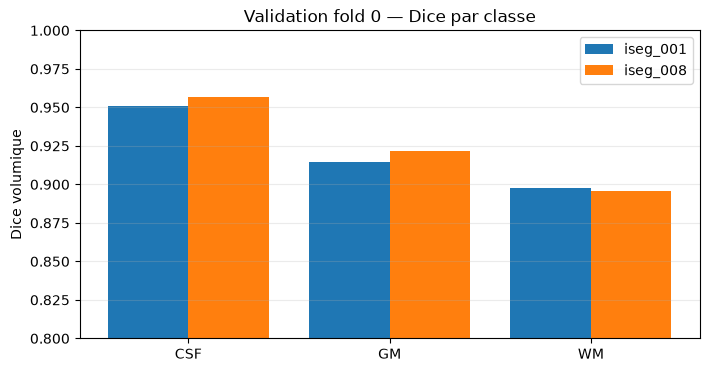

In [6]:
metric_keys = ('csf_dice', 'gm_dice', 'wm_dice', 'mean_dice', 'csf_hd95', 'gm_hd95', 'wm_hd95')
mean_metrics = {
    key: float(np.mean([record['metrics'][key] for record in records]))
    for key in metric_keys
}

header = f'{"Sujet":<10} {"CSF Dice":>10} {"GM Dice":>10} {"WM Dice":>10} {"Moyenne":>10} {"Temps":>9}'
print(header)
print('-' * len(header))
for record in records:
    m = record['metrics']
    print(f'{record["id"]:<10} {m["csf_dice"]:>10.5f} {m["gm_dice"]:>10.5f} '
          f'{m["wm_dice"]:>10.5f} {m["mean_dice"]:>10.5f} {record["seconds"]:>8.2f}s')
print('-' * len(header))
print(f'{"Moyenne":<10} {mean_metrics["csf_dice"]:>10.5f} {mean_metrics["gm_dice"]:>10.5f} '
      f'{mean_metrics["wm_dice"]:>10.5f} {mean_metrics["mean_dice"]:>10.5f}')
print(f'HD95 moyen — CSF={mean_metrics["csf_hd95"]:.3f} mm, '
      f'GM={mean_metrics["gm_hd95"]:.3f} mm, WM={mean_metrics["wm_hd95"]:.3f} mm')

classes = ('CSF', 'GM', 'WM')
x = np.arange(len(classes))
width = 0.8 / len(records)
fig, ax = plt.subplots(figsize=(8, 4))
for index, record in enumerate(records):
    values = [record['metrics'][f'{name.lower()}_dice'] for name in classes]
    ax.bar(x + (index - (len(records) - 1) / 2) * width, values, width, label=record['id'])
ax.set_xticks(x, classes)
ax.set_ylim(0.8, 1.0)
ax.set_ylabel('Dice volumique')
ax.set_title(f'Validation fold {FOLD} — Dice par classe')
ax.grid(axis='y', alpha=0.25)
ax.legend()
plt.show()

## Exemples qualitatifs

Trois coupes axiales sont choisies automatiquement dans la partie basse, centrale et haute du cerveau. La dernière colonne met en rouge tous les pixels mal classés.

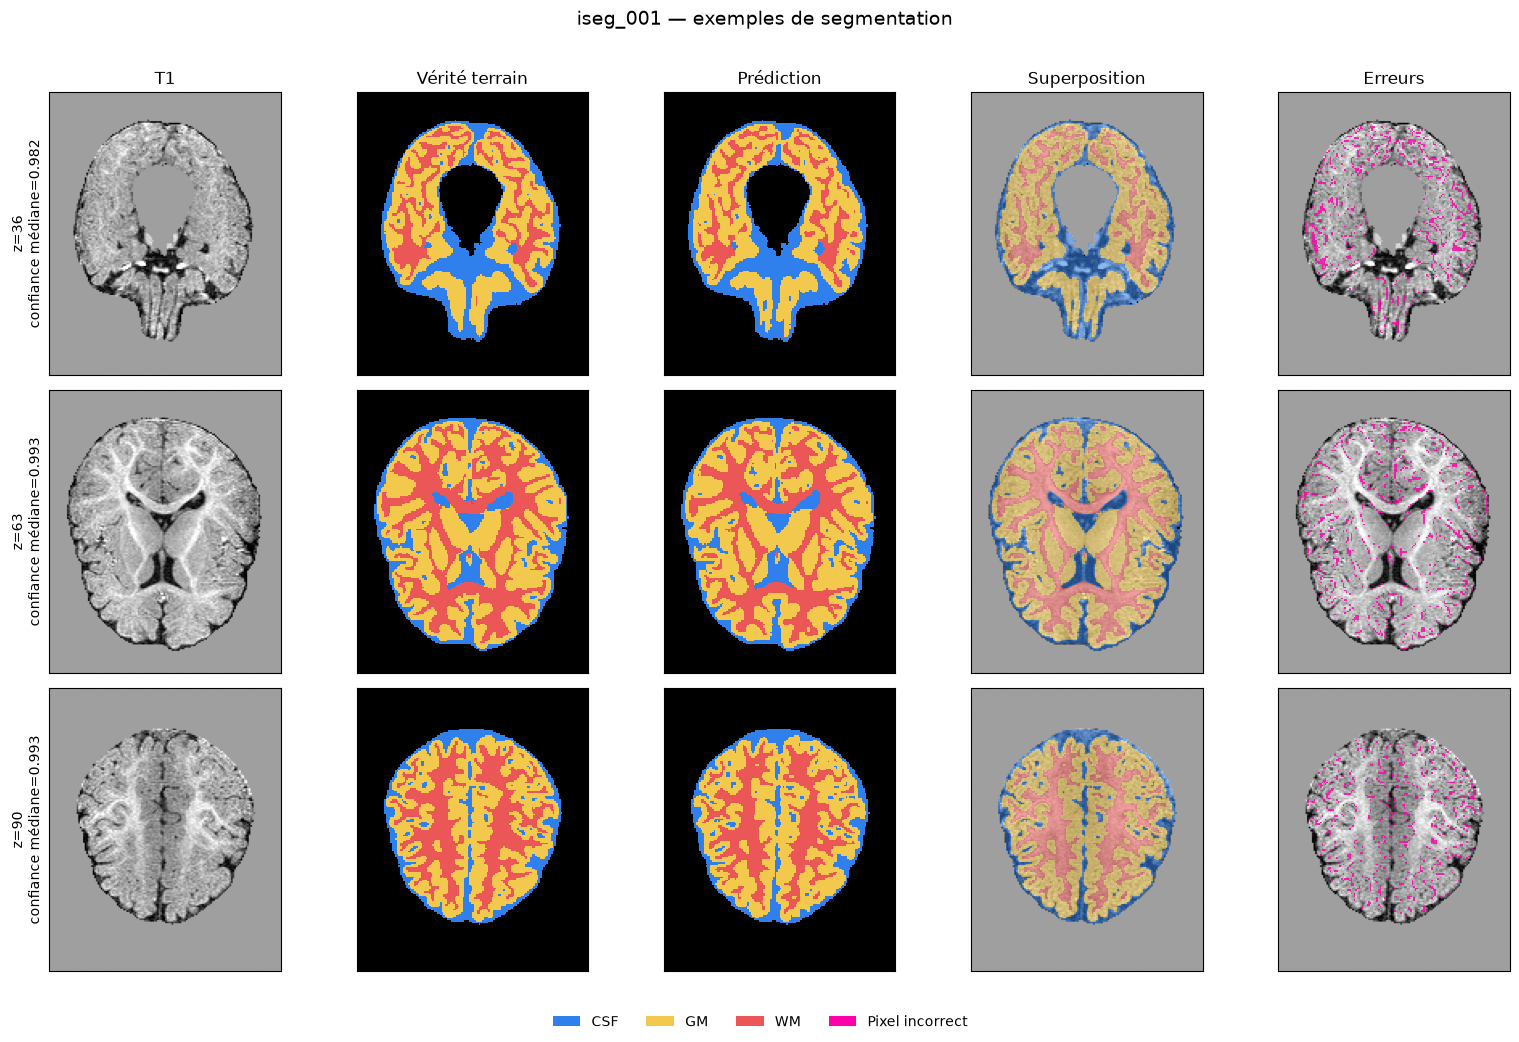

In [7]:
CLASS_NAMES = ('Fond', 'CSF', 'GM', 'WM')
CLASS_COLORS = ('#000000', '#2f80ed', '#f2c94c', '#eb5757')
SEGMENTATION_CMAP = ListedColormap(CLASS_COLORS)

record = records[DISPLAY_SUBJECT_INDEX]
target = record['target']
prediction = record['prediction']
foreground_slices = np.flatnonzero(np.any(target > 0, axis=(0, 1)))
if not len(foreground_slices):
    raise ValueError('Aucune coupe contenant du cerveau dans la cible.')
slice_indices = np.unique(np.quantile(foreground_slices, (0.25, 0.5, 0.75)).round().astype(int))

brain_intensities = record['t1'][target > 0]
vmin, vmax = np.percentile(brain_intensities, (1, 99))
fig, axes = plt.subplots(len(slice_indices), 5, figsize=(16, 3.5 * len(slice_indices)), squeeze=False)

for row, z in enumerate(slice_indices):
    image = record['t1'][:, :, z].T
    truth = target[:, :, z].T
    predicted = prediction[:, :, z].T
    confidence = record['confidence'][:, :, z].T
    errors = predicted != truth

    axes[row, 0].imshow(image, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
    axes[row, 1].imshow(truth, cmap=SEGMENTATION_CMAP, origin='lower', vmin=0, vmax=3, interpolation='nearest')
    axes[row, 2].imshow(predicted, cmap=SEGMENTATION_CMAP, origin='lower', vmin=0, vmax=3, interpolation='nearest')
    axes[row, 3].imshow(image, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
    overlay = np.ma.masked_where(predicted == 0, predicted)
    axes[row, 3].imshow(overlay, cmap=SEGMENTATION_CMAP, origin='lower', vmin=0, vmax=3, alpha=0.55, interpolation='nearest')
    axes[row, 4].imshow(image, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
    axes[row, 4].imshow(np.ma.masked_where(~errors, errors), cmap=ListedColormap(['#ff00aa']), origin='lower', alpha=0.8, interpolation='nearest')

    axes[row, 0].set_ylabel(f'z={z}\nconfiance médiane={np.median(confidence[target[:, :, z].T > 0]):.3f}')
    for axis in axes[row]:
        axis.set_xticks([])
        axis.set_yticks([])

for axis, title in zip(axes[0], ('T1', 'Vérité terrain', 'Prédiction', 'Superposition', 'Erreurs'), strict=True):
    axis.set_title(title)

legend = [Patch(facecolor=color, label=name) for name, color in zip(CLASS_NAMES[1:], CLASS_COLORS[1:], strict=True)]
legend.append(Patch(facecolor='#ff00aa', label='Pixel incorrect'))
fig.legend(handles=legend, loc='lower center', ncol=4, frameon=False)
fig.suptitle(f'{record["id"]} — exemples de segmentation', fontsize=14)
fig.tight_layout(rect=(0, 0.05, 1, 0.97))
plt.show()

## Interprétation

- Le **Dice** mesure le recouvrement ; plus il est proche de 1, mieux c'est.
- Le **HD95** mesure une distance de frontière robuste aux 5 % d'erreurs les plus extrêmes ; plus il est faible, mieux c'est.
- La matière blanche (WM) est généralement la classe la plus difficile en phase isointense.
- Deux sujets sur un seul fold donnent une démonstration, pas une estimation définitive de généralisation. Une conclusion scientifique exige les cinq folds ou l'évaluation officielle cachée.